# Global Economic and Social Trends using World Development Indicators

Project goal: “Analyze relationships between economic growth, health, and technology adoption across countries and regions using global economic and social indicators for the period of 2000 - 2017”

Economic growth and social development are deeply interconnected, yet the relationship between indicators such as GDP, life expectancy, infant mortality, unemployment, and technology adoption varies widely across countries and income groups. 

The objective of this project is to analyze global economic and social development patterns using World Development Indicators, with a focus on the relationships between wealth, health, demographics, and regional disparities. Through a combination of statistical plots, comparative charts, and interactive visualizations, the project seeks to:

1. Highlight Economic Distribution and Growth

2. Explore Health and Demographic Outcomes

3. Uncover Relationships Between Key Indicators

4. Compare Regional and Income Group Disparities


The data set has been taken from: https://mavenanalytics.io/data-playground/world-economic-indicators 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Load the Dataset: 

In [ ]:
df = pd.read_excel(r'World Economic Indicators - WorldBank.xlsx')

Basic Structure:

In [3]:
# The number of rows and columns in the dataset
df.shape

(3407, 14)

In [4]:
# A concise summary of the dataset, including the data types and non-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3407 entries, 0 to 3406
Data columns (total 14 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country Name                                3407 non-null   str    
 1   Country Code                                3407 non-null   str    
 2   Region                                      3407 non-null   str    
 3   IncomeGroup                                 3407 non-null   str    
 4   Year                                        3407 non-null   int64  
 5   Birth rate per 1000 people                  3407 non-null   float64
 6   Death rate per 1000 people                  3407 non-null   float64
 7   GDP                                         3407 non-null   int64  
 8   GDP per capita                              3407 non-null   float64
 9   Individuals using the Internet%             3333 non-null   float64
 10  Infant mortality rate p

In [5]:
# The first few rows of the dataset to get an overview of the data
df.head(10)

,Country Name,Country Code,Region,IncomeGroup,Year,Birth rate per 1000 people,Death rate per 1000 people,GDP,GDP per capita,Individuals using the Internet%,Infant mortality rate per 1000 live births,Life expectancy at birth,Population density,Unemployment%
0,Afghanistan,AFG,South Asia,Low income,2017,33.211,6.575,20191800000,556.302,13.50000,49.5,64.130,55.5960,1.559
1,Afghanistan,AFG,South Asia,Low income,2016,33.981,6.742,19362600000,547.228,11.20000,51.2,63.763,54.1971,1.634
2,Afghanistan,AFG,South Asia,Low income,2015,34.809,6.929,19907100000,578.466,8.26000,53.1,63.377,52.7121,1.679
3,Afghanistan,AFG,South Asia,Low income,2014,35.706,7.141,20484900000,613.856,7.00000,55.1,62.966,51.1148,1.735
4,Afghanistan,AFG,South Asia,Low income,2013,36.670,7.380,20561100000,637.165,5.90000,57.3,62.525,49.4280,1.725
5,Afghanistan,AFG,South Asia,Low income,2012,37.690,7.645,20001600000,641.872,5.45455,59.5,62.054,47.7306,1.692
6,Afghanistan,AFG,South Asia,Low income,2011,38.750,7.936,17804300000,591.162,5.00000,61.9,61.553,46.1315,1.984
7,Afghanistan,AFG,South Asia,Low income,2010,39.829,8.250,15856600000,543.303,4.00000,64.3,61.028,44.7041,2.275
8,Afghanistan,AFG,South Asia,Low income,2009,40.903,8.584,12439100000,438.076,3.55000,66.8,60.484,43.4930,2.470
9,Afghanistan,AFG,South Asia,Low income,2008,41.949,8.932,10109200000,364.660,1.84000,69.4,59.930,42.4628,2.494


In [6]:
# Descriptive statistics for numerical columns
df.describe()

,Year,Birth rate per 1000 people,Death rate per 1000 people,GDP,GDP per capita,Individuals using the Internet%,Infant mortality rate per 1000 live births,Life expectancy at birth,Population density,Unemployment%
count,3407.000000,3407.000000,3407.000000,3.407000e+03,3407.000000,3333.000000,3228.000000,3390.000000,3380.000000,3234.000000
mean,2008.482242,22.252033,8.339507,3.101144e+11,13017.184237,30.392103,29.346035,69.800958,316.795528,8.152408
std,5.171988,11.097848,3.354897,1.300118e+12,19820.414743,28.598251,27.019699,9.307204,1507.460708,6.186013
min,2000.000000,6.900000,1.127000,6.310130e+07,111.927000,0.000000,1.500000,39.441000,0.136713,0.140000
25%,2004.000000,12.300000,5.999000,4.803350e+09,1229.840000,4.746600,7.700000,63.966500,31.462800,3.787000
50%,2008.000000,19.799000,7.700000,2.014280e+10,4231.620000,21.000000,18.900000,72.171500,75.715000,6.582000
75%,2013.000000,30.858500,10.000000,1.345000e+11,16103.150000,53.299200,46.325000,76.580250,181.881750,10.752250
max,2017.000000,53.541000,23.594000,1.950000e+13,178846.000000,100.000000,142.400000,84.680500,21389.100000,37.250000


In [7]:
#Print the total number of countries
print(f'Total number of countries in the list: {df['Country Name'].nunique()}')

Total number of countries in the list: 195


In [8]:
# Checking for the null data
df.isnull().sum()

Country Name                                    0
Country Code                                    0
Region                                          0
IncomeGroup                                     0
Year                                            0
Birth rate per 1000 people                      0
Death rate per 1000 people                      0
GDP                                             0
GDP per capita                                  0
Individuals using the Internet%                74
Infant mortality rate per 1000 live births    179
Life expectancy at birth                       17
Population density                             27
Unemployment%                                 173
dtype: int64

Data Cleaning

In [9]:
#Filling null data with value 0, as all are different country data and these cannot be filled with average or median value

# Fill null values with 0 in Individuals using the Internet%
df['Individuals using the Internet%'] = df['Individuals using the Internet%'].fillna(0)


# Fill null values with 0 in Infant mortality rate per 1000 live births
df['Infant mortality rate per 1000 live births'] = df['Infant mortality rate per 1000 live births'].fillna(0)

# Fill null values with 0 in Life expectancy at birth
df['Life expectancy at birth'] = df['Life expectancy at birth'].fillna(0)

# Fill null values with 0 in Population density
df['Population density'] = df['Population density'].fillna(0)

# Fill null values with 0 in Unemployment%
df['Unemployment%'] = df['Unemployment%'].fillna(0)

In [10]:
df.isnull().sum()

Country Name                                  0
Country Code                                  0
Region                                        0
IncomeGroup                                   0
Year                                          0
Birth rate per 1000 people                    0
Death rate per 1000 people                    0
GDP                                           0
GDP per capita                                0
Individuals using the Internet%               0
Infant mortality rate per 1000 live births    0
Life expectancy at birth                      0
Population density                            0
Unemployment%                                 0
dtype: int64

Exploratory Data Analysis (EDA) and Visualization

1.  Boxplot of GDP per capita:

The boxplot illustrates the distribution of GDP per capita across countries from 2000 to 2017. Each box represents one year, showing the median, quartiles, and spread of GDP per capita values worldwide.

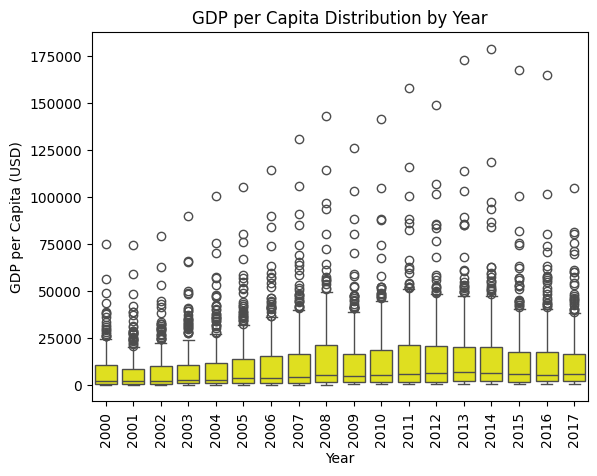

In [11]:
# Create a boxplot to show the distribution of GDP per capita across different years
sns.boxplot(x='Year', y='GDP per capita', data=df, color='yellow')

# Rotate x-axis labels by 90 degrees for readability
plt.xticks(rotation=90)

# Add a descriptive title to the chart
plt.title('GDP per Capita Distribution by Year')

# Label the y-axis to indicate the measurement unit
plt.ylabel('GDP per Capita (USD)')

# Display the plot
plt.show()

Insight:
This visualization makes clear that although global prosperity has increased over time, the gap between the richest and poorest countries remains significant. Outliers highlight nations whose economic performance far exceeds the global norm, while the majority of countries show slower, steadier growth.

2.  Bar chart of top 10 countries by GDP per capita

This horizontal bar chart highlights the ten countries with the highest average GDP per capita across all years in the dataset. It highlights the economic leaders globally by average GDP per capita. Each country is represented by a bar, with distinct colors for easy comparison

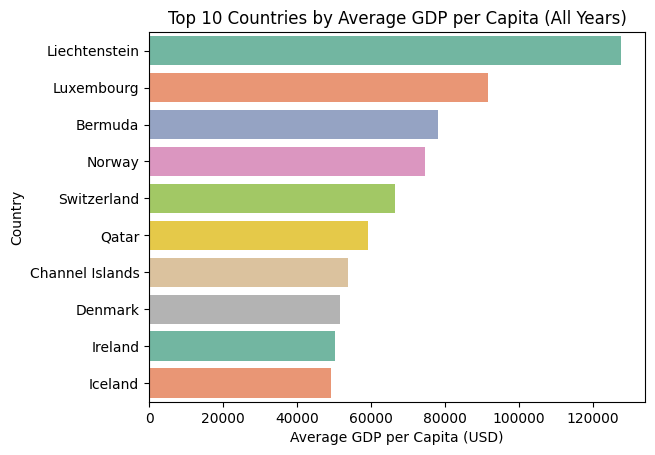

In [12]:
# Step 1: Calculate the average GDP per capita for each country
df_avg = df.groupby('Country Name')['GDP per capita'].mean().reset_index()

# Step 2: Select the top 10 countries with the highest average GDP per capita
top10_avg = df_avg.nlargest(10, 'GDP per capita')

# Step 3: Create a horizontal bar plot
sns.barplot(x='GDP per capita', y='Country Name', data=top10_avg, hue='Country Name', palette='Set2')
# hue = Country Name (adds color distinction for each bar)
# palette = 'Set2' (uses a predefined color palette for better aesthetics)

# Step 4: Add a descriptive title and axis labels
plt.title('Top 10 Countries by Average GDP per Capita (All Years)')
plt.xlabel('Average GDP per Capita (USD)')
plt.ylabel('Country')

# Step 5: Display the chart
plt.show()

Insight:

The chart emphasizes that small, highly developed nations or financial hubs dominate global wealth rankings. European countries (Liechtenstein, Luxembourg, Norway, Switzerland, Denmark, Ireland, Iceland) make up the majority, reflecting strong economies and high living standards.

3. Line chart of global average GDP per capita over time

The line chart reveals the trend of global average GDP per capita over time. It will show the periods of growth, stability, or decline. It’s useful for spotting long‑term economic progress and identifying years of global downturns.


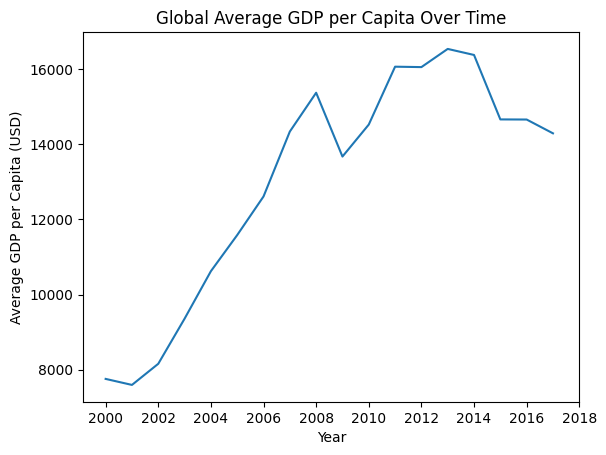

In [13]:
# Step 1: Calculate the global average GDP per capita for each year
# Group the dataset by 'Year' and compute the mean of 'GDP per capita'
# reset_index() converts the grouped result back into a clean DataFrame
global_avg = df.groupby('Year')['GDP per capita'].mean().reset_index()

# Step 2: Plot a line chart of global average GDP per capita over time
plt.plot(global_avg['Year'], global_avg['GDP per capita'])

# Step 3: Add a descriptive title and axis labels
plt.title('Global Average GDP per Capita Over Time')
plt.xlabel('Year')
plt.ylabel('Average GDP per Capita (USD)')

# Step 4: Customize x-axis ticks
# Show ticks every 2 years for readability
plt.xticks(range(global_avg['Year'].min(), global_avg['Year'].max()+2, 2))

# Step 5: Display the chart
plt.show()

Insight:

The line chart tracks the global average GDP per capita (in USD) from 2000 to 2017. The chart highlights long‑term global economic progress, with most of the early 2000s marked by rising prosperity.

Trend: The line shows a steady upward trajectory from 2000 through 2014, reflecting consistent global economic growth.

Fluctuations: Minor dips along the way suggest periods of slower growth or global economic shocks.

Decline after 2014: From 2014 to 2017, the chart shows a noticeable drop in average GDP per capita, indicating a slowdown or contraction in global prosperity during those years.

4.  Boxplot of life expectancy by income group

Plot represents the distribution of life expectancy within an income group

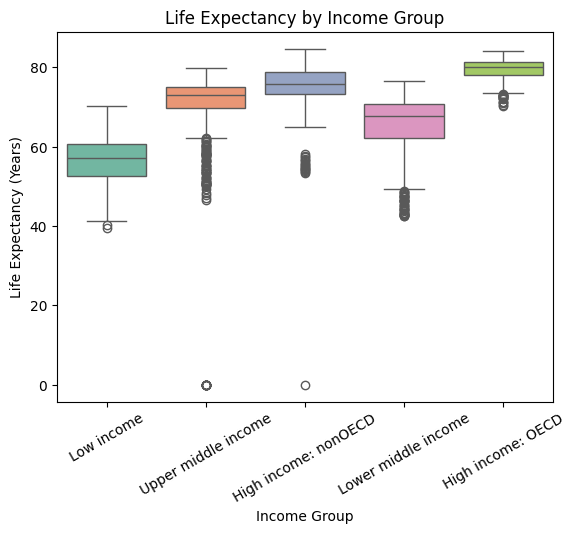

In [14]:
# Step 1: Create a boxplot to show the distribution of life expectancy across income groups
sns.boxplot(x='IncomeGroup', y='Life expectancy at birth', hue='IncomeGroup', data=df, palette='Set2')
# hue = IncomeGroup (adds color distinction for each group)
# palette = 'Set2' (uses a predefined color palette for better aesthetics)

# Step 2: Add a descriptive title and axis labels
plt.title('Life Expectancy by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Life Expectancy (Years)')

# Step 3: Rotate x-axis labels slightly for readability
plt.xticks(rotation=30)

# Step 4: Display the chart
plt.show()

5. Correlation heatmap (GDP per capita vs Life expectancy and Population density

The heatmap makes it easy to visually compare the strength of these relationships. This heatmap visualizes the correlation coefficients between three key variables:

GDP per capita

Life expectancy at birth

Population density

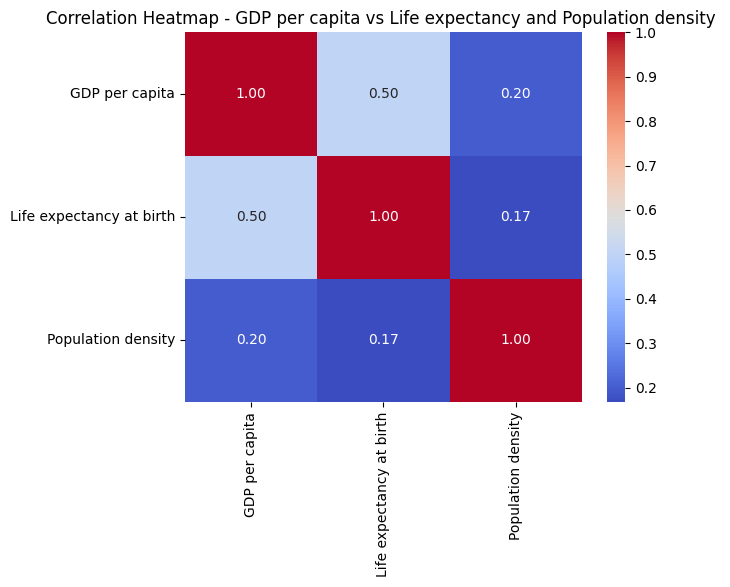

In [15]:
# Step 1: Select relevant columns for correlation analysis
# GDP per capita, Life expectancy at birth, and Population density
selected = df[['GDP per capita','Life expectancy at birth','Population density']]

# Step 2: Compute the correlation matrix
corr_selected = selected.corr() # This shows how strongly each variable is related to the others

# Step 3: Create a heatmap to visualize the correlation matrix
sns.heatmap(corr_selected, annot=True, cmap='coolwarm', fmt='.2f')
# annot=True → displays correlation values inside each cell
# cmap='coolwarm' → uses a diverging color palette (blue to red)
# fmt='.2f' → formats correlation values to 2 decimal places

# Step 4: Add a descriptive title
plt.title('Correlation Heatmap - GDP per capita vs Life expectancy and Population density ')

# Step 5: Display the chart
plt.show()

Insights:

GDP per capita vs. Life expectancy → moderate positive correlation (around 0.50).

GDP per capita vs. Population density → weak positive correlation (around 0.20).

Life expectancy vs. Population density → very weak correlation (around 0.17).

6. Pairplot : GDP per capita, population density, life expectancy(to see relationships)

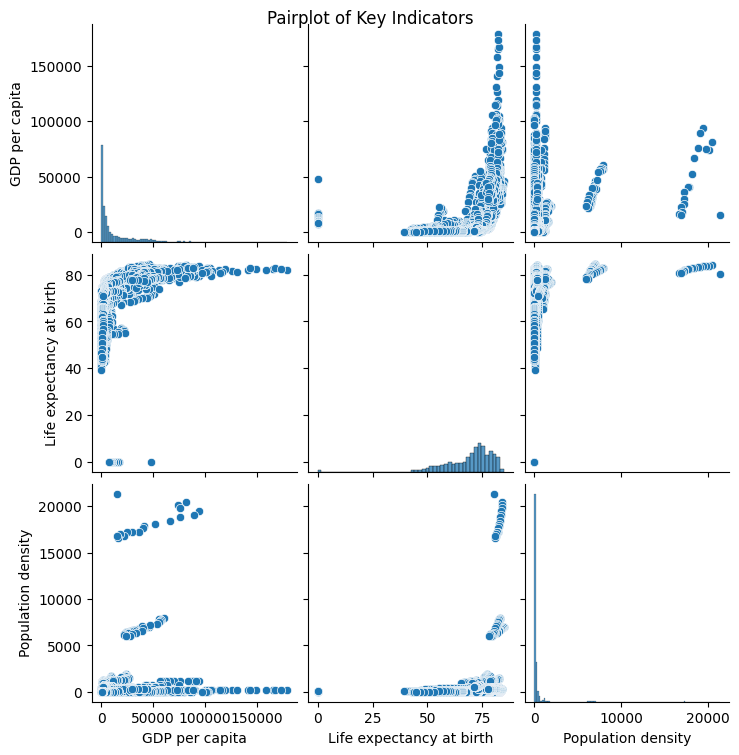

In [16]:
# Step 1: Create a pairplot to visualize relationships between selected indicators
sns.pairplot(selected) 
# 'selected' is a DataFrame containing GDP per capita, Life expectancy at birth, and Population density
# sns.pairplot() automatically creates scatter plots for each pair of variables and histograms/boxplots along the diagonal to show distributions


# Step 2: Add a descriptive overall title to the figure
plt.suptitle('Pairplot of Key Indicators', y=1)
# suptitle() adds a title to the entire plot grid
# y=1 adjusts the vertical position of the title so it doesn’t overlap with the plots

# Step 3: Display the chart
plt.show()

Insights:

The strongest relationship is between GDP per capita and life expectancy, reinforcing the idea that economic development supports better health outcomes.

Population density shows wide variation but little direct influence on either GDP or life expectancy.


7. Interactive scatter plot using Plotly to explore the relationships between GDP per capita, life expectancy, population density, and region

In [17]:
# Step 1: Create a scatter plot to show the relationship between GDP per capita and life expectancy
fig = px.scatter(df, 
                 x='GDP per capita', 
                 y='Life expectancy at birth',
                 size='Population density', # bubble size represents density
                 color='Region',
                 hover_name='Country Name', # shows country name when hovering over a point
                 log_x=True,  # log scale applied for better visualization of wide ranges
                 color_discrete_sequence=px.colors.qualitative.Set2) # color_discrete_sequence = Set2 palette for consistent aesthetics

# Step 2: Display the interactive chart
fig.show()


In [ ]:
# Import Plotly's input/output module
import plotly.io as pio

# Save a Plotly figure (fig) as an HTML file so that it can be viewed in github with the help of the browser
pio.write_html(fig, file="plot.html", auto_open=False)

[Open interactive plot](https://steffy-joy.github.io/Global-Economic-and-Social-Trends-Analysis/plot.html)

It reveals whether the global pattern (wealth → health) holds consistently across regions or varies due to local factors.

8. Grouped bar chart comparing GDP per capita across regions (e.g., continents) for a given year

Creates visual for comparing continents or regions side‑by‑side in each year. The grouped format makes it easy to compare regions within the same year and observe trends across years.

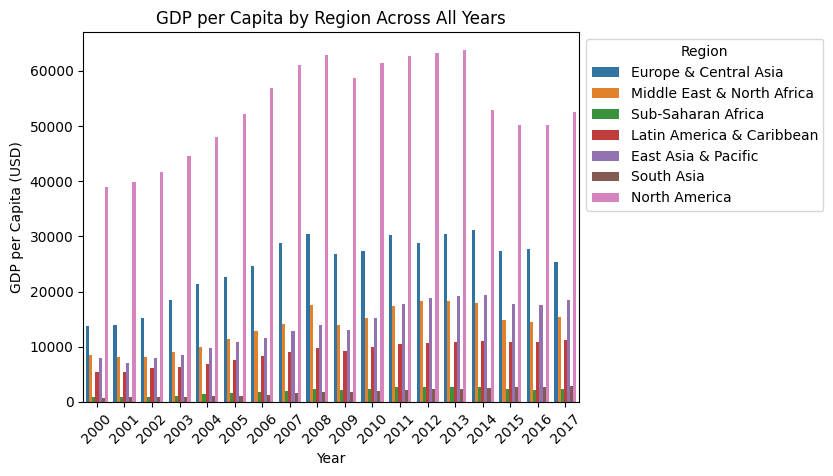

In [19]:
# Step 1: Create a grouped bar plot to show GDP per capita by region across all years
sns.barplot(x='Year', y='GDP per capita', hue='Region', data=df, errorbar=None)
# hue = Region (different colors for each region)
# errorbar=None → removes error bars for a cleaner look

# Step 2: Add a descriptive title and axis labels
plt.title('GDP per Capita by Region Across All Years')
plt.xlabel('Year')
plt.ylabel('GDP per Capita (USD)')

# Step 3: Rotate x-axis labels by 45 degrees for readability
plt.xticks(rotation=45)

# Step 4: Add a legend to identify regions
plt.legend(title='Region', bbox_to_anchor=(1, 1))
# title='Region' → labels the legend
# bbox_to_anchor=(1, 1) → positions the legend outside the plot for clarity

# Step 5: Display the chart
plt.show()

Insights:

North America consistently has the highest GDP per capita across all years.

Sub‑Saharan Africa and South Asia remain at the lower end, highlighting persistent economic disparities.

9. Stacked bar chart of birth vs. death rates by income group

Provides a clear comparative view of how birth and death rates interact to shape population trends. Each stacked bar represents the combined birth and death rates for an income group.

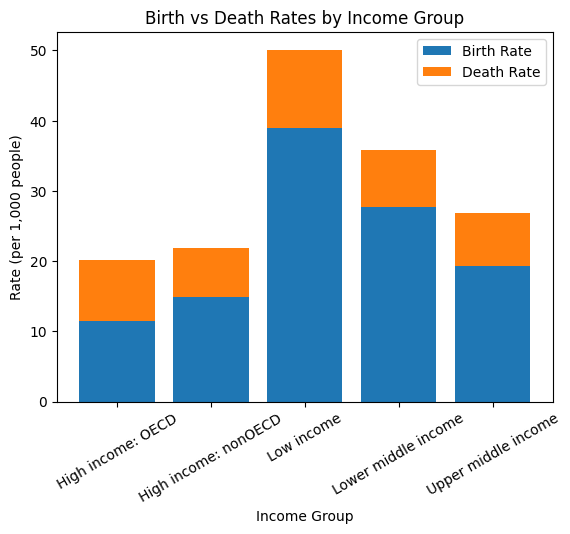

In [20]:
# Step 1: Calculate the average birth and death rates for each income group
rates = df.groupby('IncomeGroup')[['Birth rate per 1000 people','Death rate per 1000 people']].mean().reset_index()
# Group the dataset by 'IncomeGroup' and compute the mean of both rates
# reset_index() converts the grouped result back into a clean DataFrame

# Step 2: Plot the birth rates as the base bars
plt.bar(rates['IncomeGroup'], rates['Birth rate per 1000 people'], label='Birth Rate')

# Step 3: Plot the death rates stacked on top of the birth rates
plt.bar(rates['IncomeGroup'], rates['Death rate per 1000 people'], 
        bottom=rates['Birth rate per 1000 people'], label='Death Rate') # bottom=rates['Birth rate per 1000 people'] ensures the death rate bars are stacked above

# Step 4: Add a descriptive title and axis labels
plt.title('Birth vs Death Rates by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Rate (per 1,000 people)')

# Step 5: Rotate x-axis labels slightly for readability
plt.xticks(rotation=30)

# Step 6: Add a legend to distinguish birth and death rates
plt.legend(bbox_to_anchor=(1,1)) # positions the legend outside the plot for clarity

Insights:

Low‑income countries show the highest combined rates, with birth rates much higher than death rates, indicating rapid population growth.

High‑income groups (OECD and non‑OECD) have lower overall rates, reflecting both lower birth rates and lower death rates, consistent with demographic transition patterns.

Middle‑income groups fall between these extremes, showing moderate birth and death rates.

10. Scatter plot with regression line: GDP vs. infant mortality

Demonstrates how economic development is linked to better health outcomes.

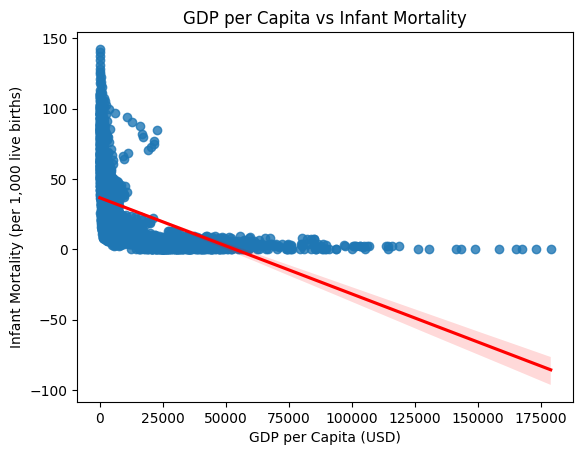

In [21]:
# Step 1: Create a scatter plot with a regression line
sns.regplot(x='GDP per capita', 
            y='Infant mortality rate per 1000 live births', 
            data=df, 
            line_kws={'color':'red'}) # styles the regression line in red

# Step 2: Add a descriptive title
plt.title('GDP per Capita vs Infant Mortality')

# Step 3: Label the axes
plt.xlabel('GDP per Capita (USD)')
plt.ylabel('Infant Mortality (per 1,000 live births)')

# Step 4: Display the chart
plt.show()

Insights:

1. The regression line slopes downward, showing a negative correlation: Countries with higher GDP per capita tend to have lower infant mortality rates.
2. Low income countries cluster on the left side of the chart, with higher infant mortality.
3. High income countries cluster on the right side, with very low infant mortality.


11. Stacked area chart: Contribution of regions to global GDP per capita over time 

Analyzing long‑term trends and the balance of economic power across continents

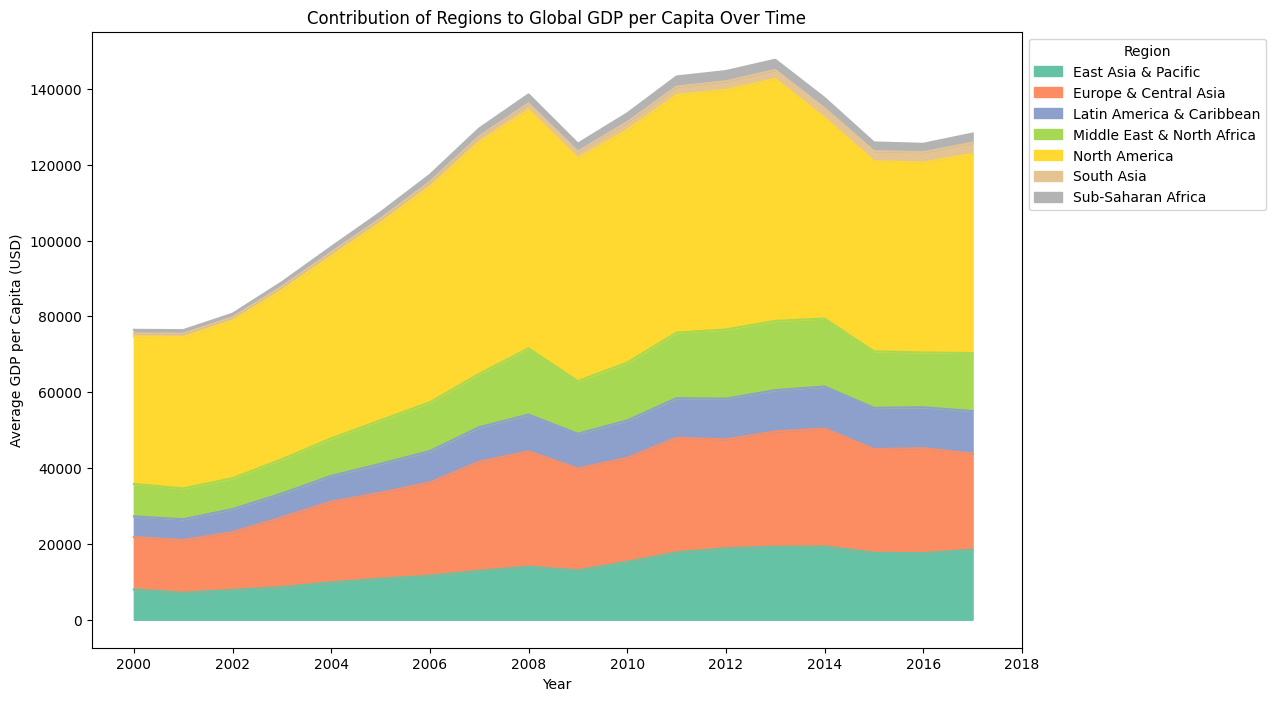

In [22]:
# Step 1: Compute the average GDP per capita per region per year
# Group the dataset by 'Year' and 'Region', then calculate the mean GDP per capita
region_gdp = df.groupby(['Year','Region'])['GDP per capita'].mean().reset_index()

# Step 2: Pivot the data for stacked area chart format
pivot = region_gdp.pivot(index='Year', columns='Region', values='GDP per capita') # Rows = Years, Columns = Regions, Values = Average GDP per capita

# Step 3: Plot a stacked area chart
pivot.plot.area(figsize=(12,8), cmap='Set2')
# figsize=(12,8) → sets chart size
# cmap='Set2' → uses a predefined color palette for regions

# Step 4: Add a descriptive title and axis labels
plt.title('Contribution of Regions to Global GDP per Capita Over Time')
plt.xlabel('Year')
plt.ylabel('Average GDP per Capita (USD)')

# Step 5: Customize x-axis ticks
# Show ticks every 2 years for readability
plt.xticks(range(global_avg['Year'].min(), global_avg['Year'].max()+2, 2))

# Step 6: Add a legend to identify regions
plt.legend(bbox_to_anchor=(1,1), title='Region') # bbox_to_anchor=(1,1) → positions the legend outside the plot

# Step 7: Display the chart
plt.show()

Insights:

The chart shows an overall upward trend in global GDP per capita from 2000 to around 2014, followed by a slight decline and stabilization.

North America consistently contributes the largest share, dominating global GDP per capita.

Europe & Central Asia and East Asia & Pacific are the next largest contributors, reflecting strong economies.

Latin America & Caribbean, Middle East & North Africa, South Asia, and Sub‑Saharan Africa contribute smaller shares, highlighting disparities.

# Conclusion

Across all the charts — from correlation heatmaps and pairplots to scatter plots, bar charts, and stacked area charts — a consistent story emerges: economic development is strongly linked to health outcomes and demographic patterns, while regional disparities remain significant.

       Insight Summary
1. Wealth and Health Connection

       . Higher GDP per capita is consistently associated with longer life expectancy and lower infant mortality.

       . Regression analyses and scatter plots reinforce this negative correlation between wealth and mortality.

2. Population Density’s Limited Role

       . While population density varies widely, it shows only weak correlations with GDP and life expectancy.

       . Density adds context but is not a primary driver of health or wealth outcomes.

3. Regional Disparities

       . North America and Europe & Central Asia lead in GDP per capita, life expectancy, and low mortality.

       . Sub‑Saharan Africa and South Asia remain at the lower end, with higher birth rates, higher mortality, and lower GDP per capita.

       . Middle‑income regions (Latin America, East Asia, MENA) occupy the middle ground, showing gradual improvements.

4. Demographic Transition Patterns

       . Low‑income countries: high birth rates, higher death rates → rapid population growth but health challenges.

       . High‑income countries: low birth and death rates → stable or aging populations.

       . This transition explains the stacked bar chart differences across income groups.

5. Global Trends Over Time

       . Stacked area charts show global GDP per capita rising steadily from 2000 to mid‑2010s, then stabilizing.

       . Regional contributions highlight the growing role of East Asia & Pacific, alongside the dominance of North America and Europe.